In [ ]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor

In [15]:
from lib.cifar10_data import load_data
from lib.path import data_path

# 데이터 불러오기

In [ ]:
training_data = load_data(data_path(), transform=ToTensor())

test_data = load_data(data_path(), train=False, transform=ToTensor())

c:\study\dl-with-pytorch\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# 이미지 확인

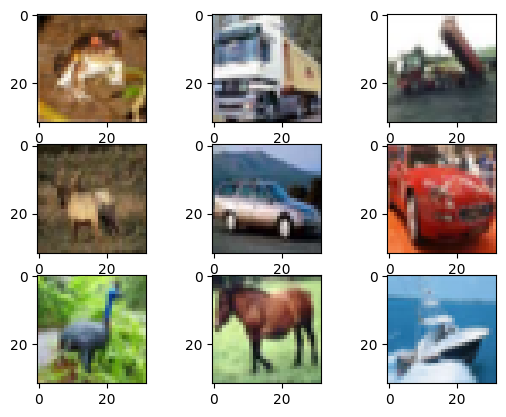

In [17]:
for i in range(9):  # 반복문으로 9개를 i로 하나씩 꺼내서 불러오는데
    plt.subplot(3, 3, i + 1)  # 그림판을 격자로 나눠서 여러 그래프를 그리게 해주는 함수
    # 이미지 4개를 한 화면에 보여주고 싶을 때, 그래프 여러 개를 비교하고 싶을 때 사용
    # (행 개수, 열 개수, 몇 번째 칸인지)
    # i+1인 이유는 subplot 위치는 1부터 시작하기 때문

    plt.imshow(training_data.data[i])
    # 배열 인덱스는 0부터 시작하기 떄문에 i에 +1을 해줘서 그래프에 표시
plt.show()

# 데이터 증강
### 데이터 증강이란 기존 데이터를 인위적으로 변형해서 학습 데이터를 늘리는 기법
#### 그림을 뒤집거나, 색을 바꾸는걸 통해서 학습 데이터를 늘린다

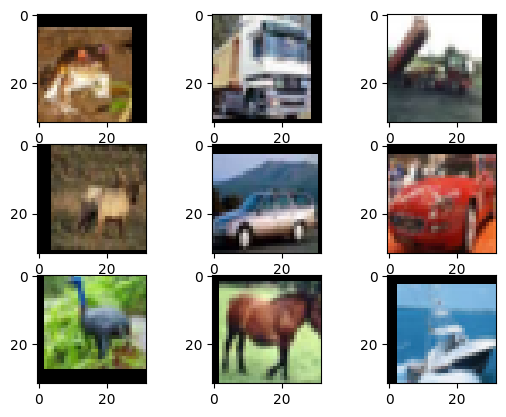

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.transforms import Compose, RandomCrop, RandomHorizontalFlip

transforms = Compose(  # 데이터 전처리 함수
    [
        T.ToPILImage(),
        RandomCrop((32, 32), padding=4),  # 랜덤으로 이미지 일부 제거 후 패딩
        # 이미지의 일부를 제거한 뒤 size 크기로 복원한다
        RandomHorizontalFlip(p=0.5),  # y축으로 기준으로 대칭
        # p확률로 이미지를 좌우대칭시킨다.
    ]
)

training_data = load_data(data_path(), transform=ToTensor())

test_data = load_data(data_path(), train=False, transform=ToTensor())

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(transforms(training_data.data[i]))

plt.show()

# 이미지 정규화
## 이미지 픽셀 값을 일정한 범위로 맞추는 작업
### 정규화 후 평균 0, 표준편차 1 근처가 된다
#### 정규화를 하면 학습 속도가 빨라지고, 성능이 향상되고, 성능이 향상된다

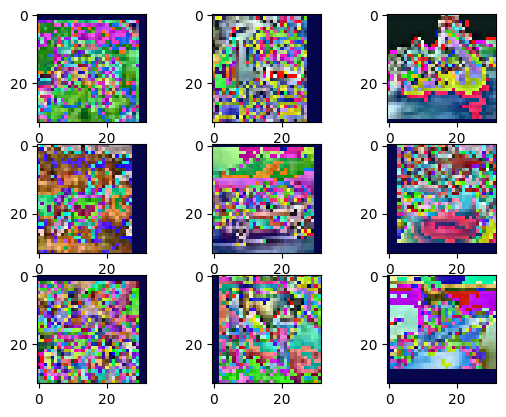

In [19]:
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.transforms import Compose, Normalize, RandomCrop, RandomHorizontalFlip

# 데이터 전처리 정의
transforms = Compose(
    [
        T.ToPILImage(),
        RandomCrop((32, 32), padding=4),
        RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.243, 0.261)),
        T.ToPILImage(),
    ]
)

# 학습용 데이터 정의
training_data = load_data(data_path(), transform=ToTensor())

# 평가용 데이터 정의
test_data = load_data(data_path(), train=False, transform=ToTensor())

# 이미지 표시
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(transforms(training_data.data[i]))
plt.show()

# 데이터셋의 평균과 표준편차

In [20]:
import torch

training_data = load_data(data_path(), transform=ToTensor())

# item[0]은 이미지, item[1]은 정답 레이블
imgs = [item[0] for item in training_data]

# imgs를 하나로 합침
imgs = torch.stack(imgs, dim=0).numpy()

# rgb 각 평균
mean_r = imgs[:, 0, :, :].mean()
mean_g = imgs[:, 1, :, :].mean()
mean_b = imgs[:, 2, :, :].mean()
print(mean_r, mean_g, mean_b)

# rgb 각 표준편차
std_r = imgs[:, 0, :, :].std()
std_g = imgs[:, 1, :, :].std()
std_b = imgs[:, 2, :, :].std()
print(std_r, std_g, std_b)

0.49139968 0.48215827 0.44653124
0.24703223 0.24348514 0.26158786


# VGG 기본 블록 정의

In [21]:
import torch
import torch.nn as nn


class BasicBlock(nn.Module):  # 기본 블록 정의
    # 기본 블록을 구성하는 층 정의
    def __init__(self, in_channels, out_channels, hidden_dim):
        # nn.Module 클래스의 요소 상속
        super().__init__()
        # 합성곱층 정의
        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        # stride는 커널의 이동 거리
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):  # 기본 블록의 순전파 정의
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        return x

# VGG 모델 정의하기

In [22]:
class CNN(nn.Module):
    def __init__(self, num_classes):  # num_class는 클래스 개수
        super().__init__

        # 합성곱 기본 블록 정의
        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        # 분류기 정의
        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        # 분류기의 활성화 함수
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)  # 출력 모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1)  # 2차원 특징 맵을 1차원으로

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

# 134p

# 데이터 증강 정의

In [25]:
from torch.utils.data.dataloader import DataLoader

transforms = Compose(
    [
        RandomCrop(
            (32, 32), padding=4
        ),  # padding=4 는 자르기 전에 이미지 바깥쪽에 4픽셀씩 여백을 추가한다
        RandomHorizontalFlip(p=0.5),
        ToTensor(),
        Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.243, 0.261)),
    ]
)

# 데이터 로드 및 모델 정의

In [ ]:
# 학습용 데이터와 평가용 데이터 불러오기
training_data = load_data(data_path(), transform=ToTensor())
test_data = load_data(data_path(), train=False, transform=ToTensor())

# 데이터로더 정의
train_loader = DataLoader(training_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=True)

# 학습을 진행할 프로세서 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)